# Projekt: Credit Card Fraud Detection (Detekcja Anomalii - Logistic Regression vs Random Forest) 
    
Dataset: `https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data`

# 1. Przygotowanie datasetu - import bibliotek + załadowanie dataset'u

In [18]:
# Podstawowe biblioteki
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Scikit-learn - preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Scikit-learn - modele
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix

import kagglehub


path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Ścieżka do pobranych plików:", path)

# Kagglehub pobiera pliki do dziwnych folderów w cache.
# Musimy znaleźć plik CSV w tym folderze:
csv_file = os.path.join(path, "creditcard.csv")

# Wczytanie
df = pd.read_csv(csv_file)

print(df.info())

print("Pomyślnie załadowano dataset!")

Ścieżka do pobranych plików: /home/wiktor/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-nu

# 2. Pierwsze wizualizacjie (plotting)

### Cel: zwizualizować, że w wybranym datasecie transakcje oszustwa to 0.2%

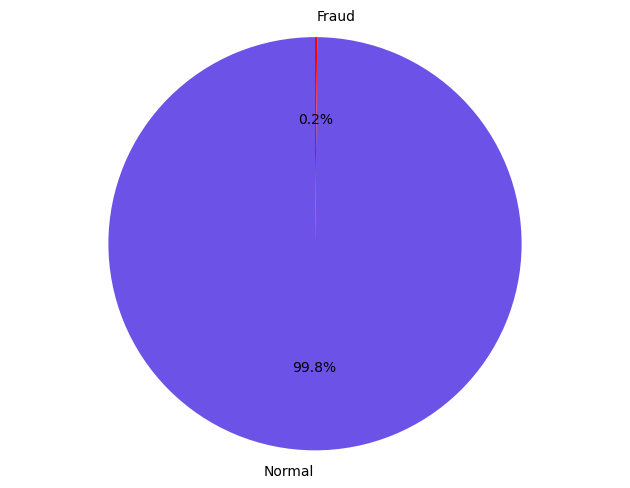

In [19]:

colors = ["#6D52E7", "#FF0000"]

plt.pie(
    df['Class'].value_counts(),
    shadow = False,
    colors = colors,
    startangle=90,
    autopct='%1.1f%%',
    labels = ['Normal', 'Fraud']
)
plt.axis('equal')
plt.tight_layout()
plt.show()


## Wniosek: dataset jest ekstremalnie niezbalansowany

### 2.1 Heatmap korelacji (plotting)

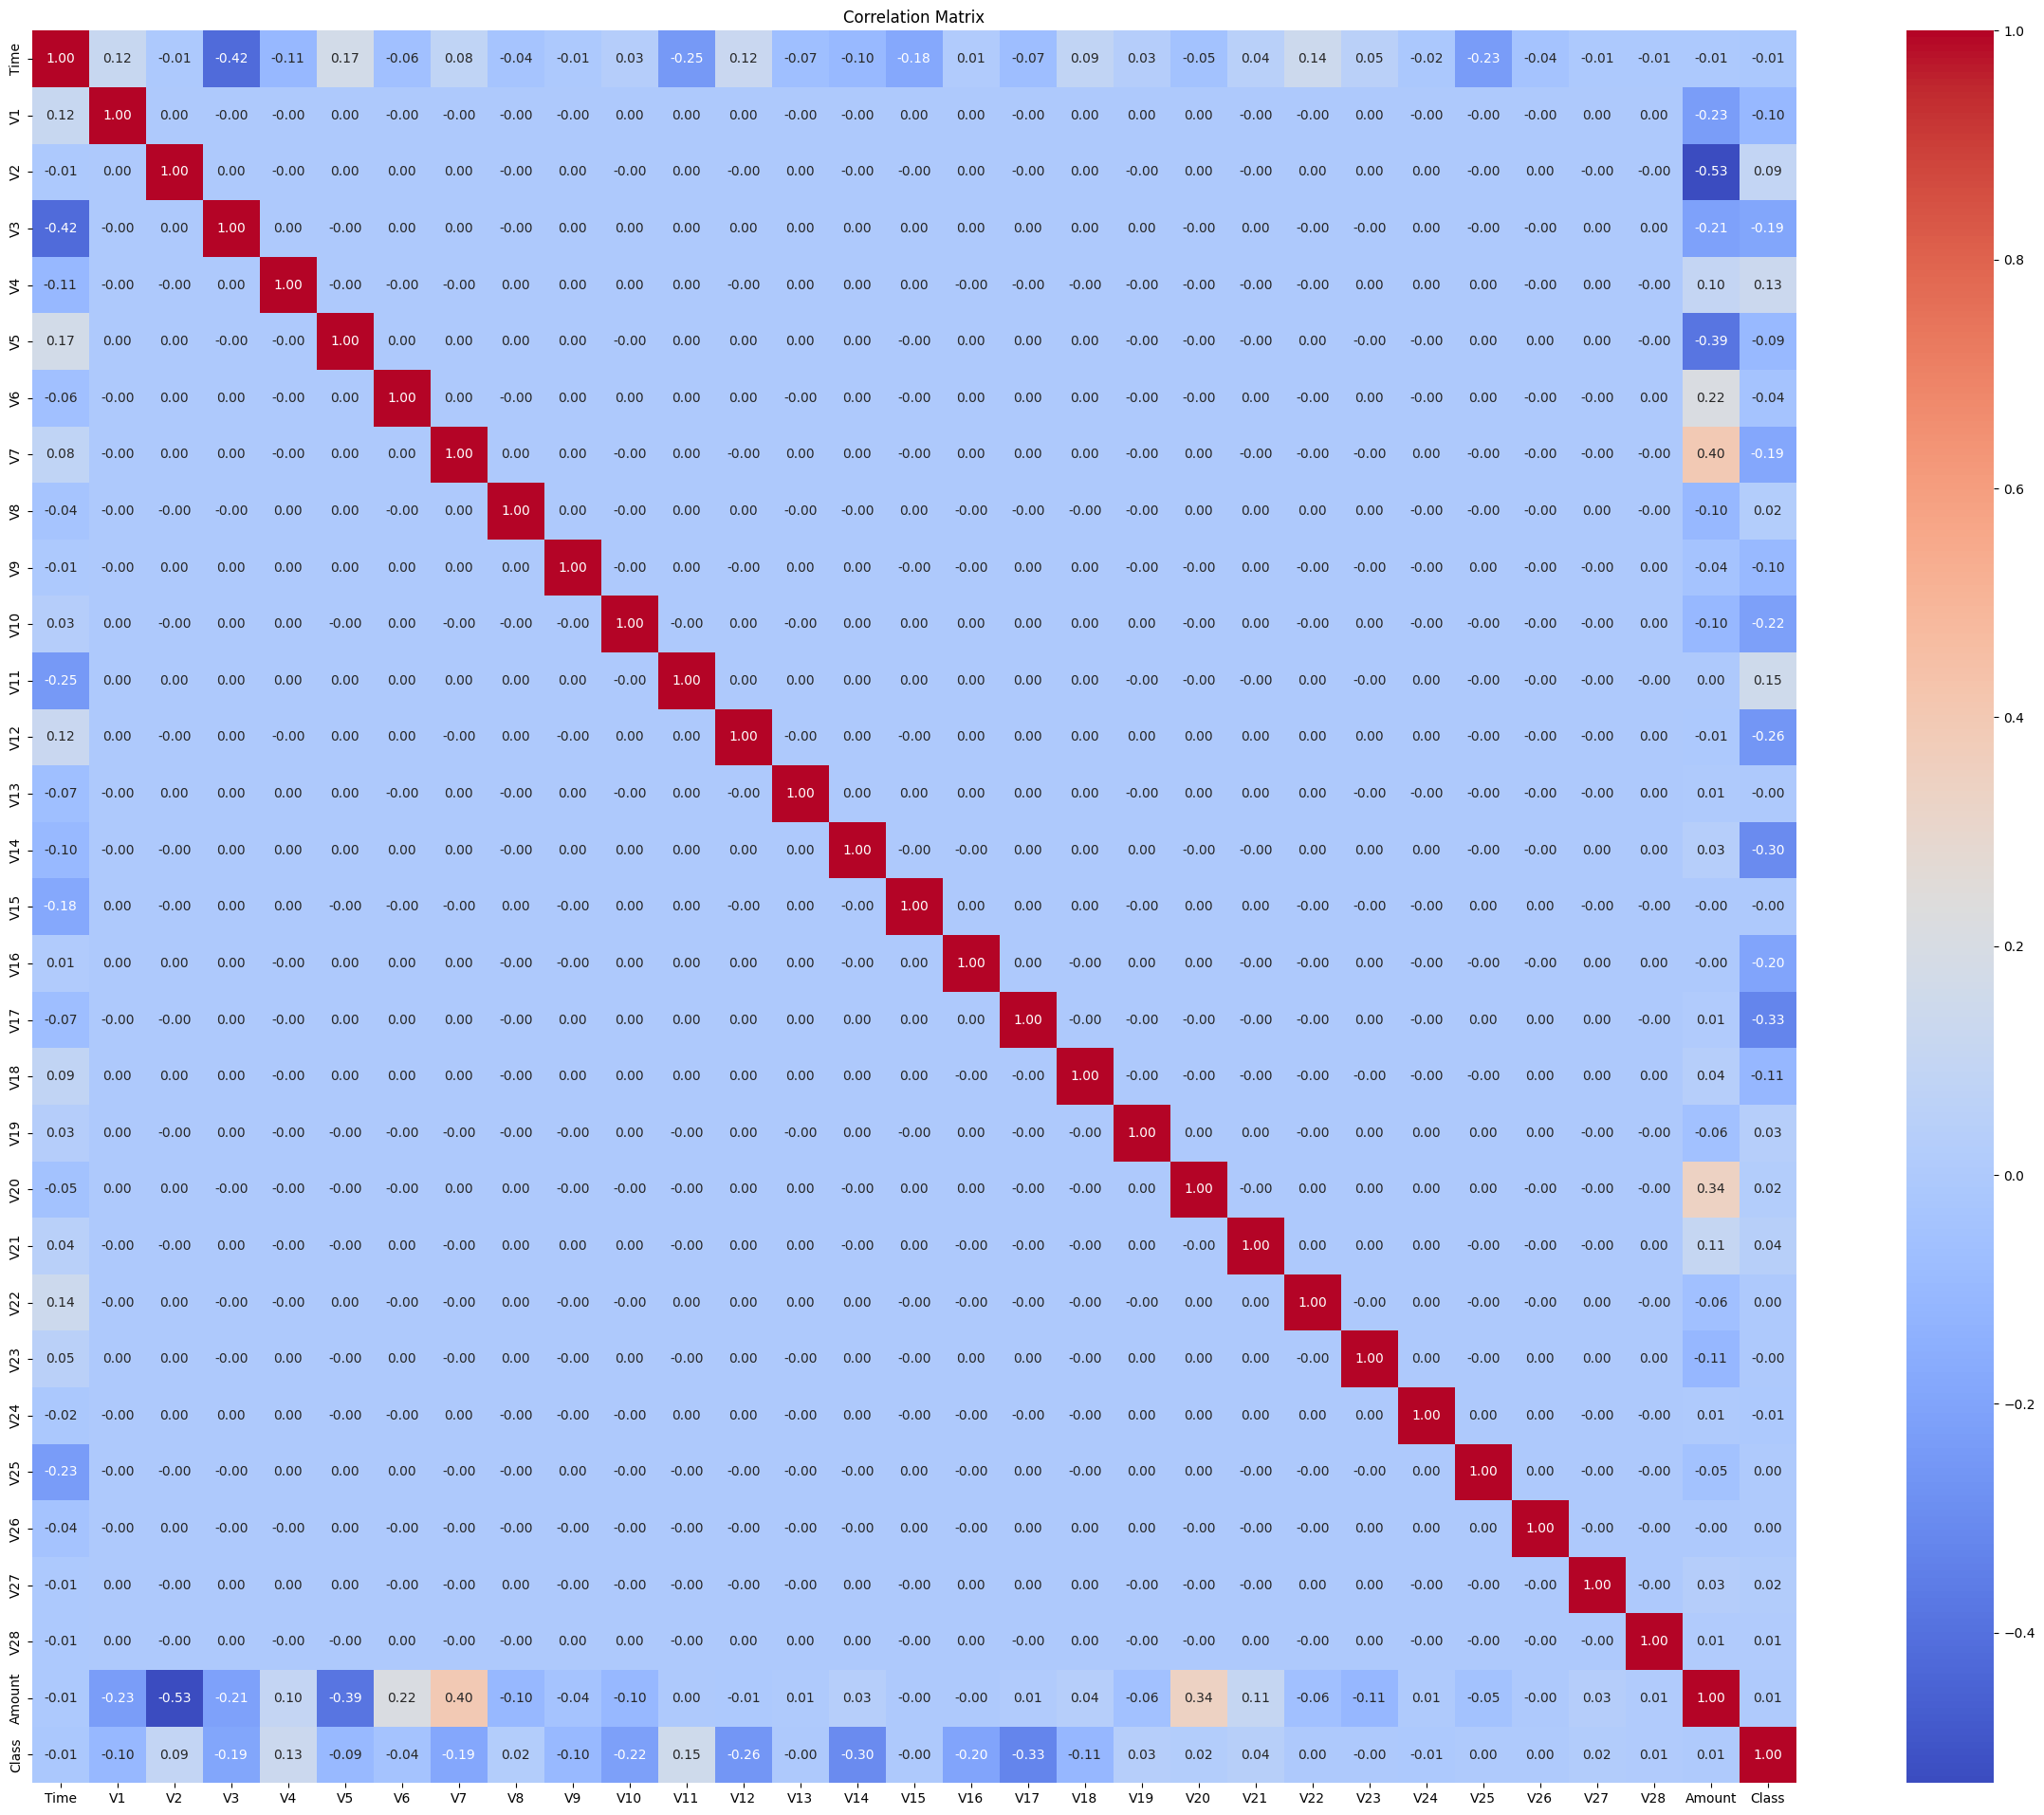

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [20]:
plt.figure(figsize=(30, 24))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

print(df.corr()['Class'].sort_values(ascending=False))


## Z Class najbardziej korelują cechy:
    1. V17 -0.33
    2. V14 -0.30
    3. V12 -0.26

# 3. Preprocessing danych

### Dataset z kaggle ma już większość danych po preprocessingu, więc pozostało dostosować kolumnę `Amount` oraz `Time`

In [21]:
X = df.drop('Class', axis=1)
y = df['Class']

print("Kształt X:", X.shape)
print("Kształt y:", y.shape)

Kształt X: (284807, 30)
Kształt y: (284807,)


# 4. Podzial na zbior treningowy i testowy
Przygotowujemy dane i zachowujemy proporcje klas (stratyfikacja).


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.copy()
X_test = X_test.copy()

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (227845, 30) Test shape: (56962, 30)


# 4.1 Skalowanie danych

In [23]:
from sklearn.preprocessing import RobustScaler

scaler_amount = RobustScaler()
scaler_time = RobustScaler()

# Skalowanie Amount
X_train['scl_amount'] = scaler_amount.fit_transform(X_train[['Amount']])
X_test['scl_amount'] = scaler_amount.transform(X_test[['Amount']])

# Skalowanie Time
X_train['scl_time'] = scaler_time.fit_transform(X_train[['Time']])
X_test['scl_time'] = scaler_time.transform(X_test[['Time']])

# Usuwamy oryginalne kolumny (nie są już potrzebne)
X_train.drop(['Time', 'Amount'], axis=1, inplace=True)
X_test.drop(['Time', 'Amount'], axis=1, inplace=True)

print("Skalowanie zakończone poprawnie.")
print("Kolumny w X_train:", X_train.columns)

print('\nRozkład klas (train):')
print(y_train.value_counts(normalize=True))
print('Rozkład klas (test):')
print(y_test.value_counts(normalize=True))

Skalowanie zakończone poprawnie.
Kolumny w X_train: Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'scl_amount',
       'scl_time'],
      dtype='object')

Rozkład klas (train):
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64
Rozkład klas (test):
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


# 5. Trenowanie i ewaluacja modeli
## Logistic Regression vs Random Forest


In [24]:
# Funkcja ewaluacyjna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, RocCurveDisplay, PrecisionRecallDisplay, recall_score, precision_score, f1_score
)

def evaluate_model(model, X_test, y_test, model_name):
    print(f"--- Result: {model_name} ---")
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(classification_report(y_test, y_pred, digits=4))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax[0], name=model_name)
    ax[0].set_title(f"ROC Curve ({model_name})")
    
    PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=ax[1], name=model_name)
    ax[1].set_title(f"Precision-Recall Curve ({model_name})")
    
    plt.tight_layout()
    plt.show()

    results = {
        'Model': model_name,
        'ROC AUC': roc_auc_score(y_test, y_proba),
        'PR AUC': average_precision_score(y_test, y_proba),
        'Recall (Fraud)': recall_score(y_test, y_pred),
        'Precision (Fraud)': precision_score(y_test, y_pred),
        'F1-Score (Fraud)': f1_score(y_test, y_pred)
    }
    return results

# 5.1 Trenowanie Logistic Regression

- liczba iteracji 1000
- class weight 'balanced' konieczne dla niezbalansowanego datasetu

Logistic Regression training...
--- Result: Logistic Regression ---
              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0609    0.9184    0.1142        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5509     56962
weighted avg     0.9982    0.9755    0.9861     56962



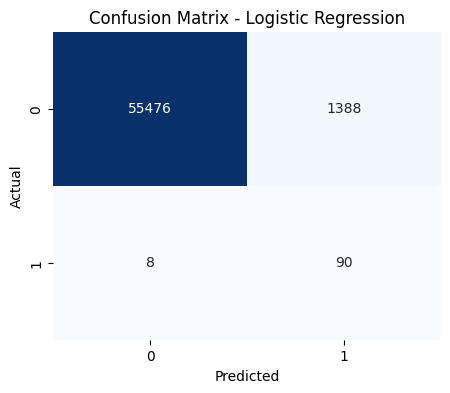

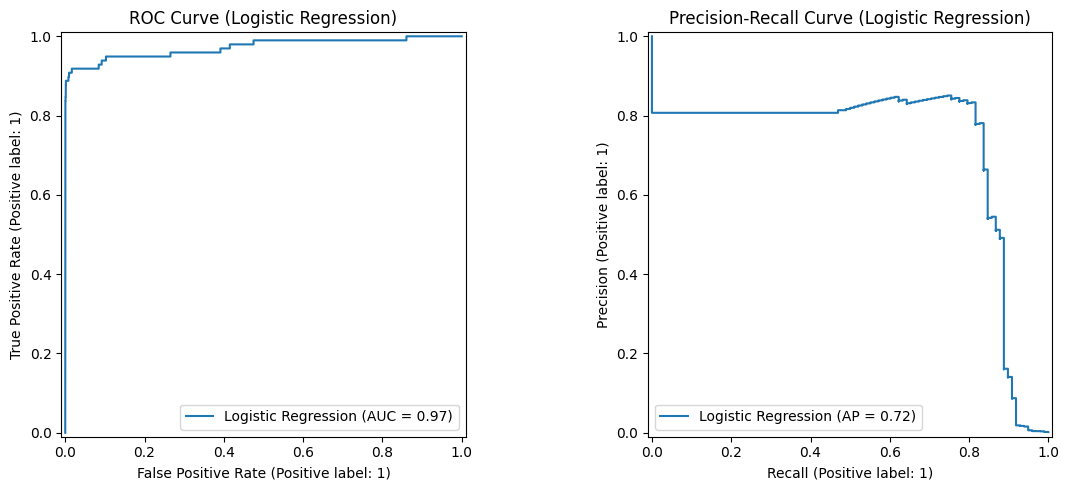

In [25]:
print("Logistic Regression training...")
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
)
lr_model.fit(X_train, y_train)
lr_results = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")

# 5.2 Trenowanie Random Forest

- trenujemy na 100 drzewach decyzyjnych
- maxymalna głębokość zapytań to 10
- waga klas 'balanced' jest konieczna w przypadku niezbalansowanego datasetu

Random Forest training...
--- Result: Random Forest ---
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56864
           1     0.8081    0.8163    0.8122        98

    accuracy                         0.9994     56962
   macro avg     0.9039    0.9080    0.9059     56962
weighted avg     0.9994    0.9994    0.9994     56962



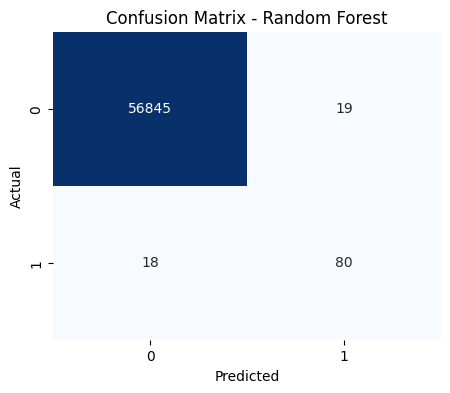

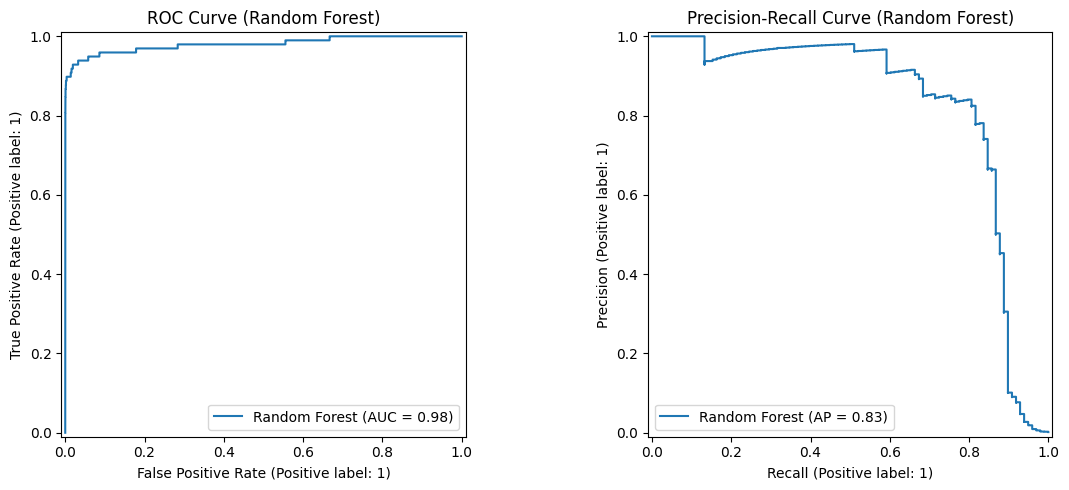

In [26]:
print("Random Forest training...")
rf_model = RandomForestClassifier(
    n_estimators=100,      
    max_depth=10,           
    class_weight='balanced',
    random_state=42,
    n_jobs=-1             
)
rf_model.fit(X_train, y_train)
rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest")

# 5.3 Ewaluacja i porównanie


--- ZESTAWIENIE WYNIKÓW ---
                      ROC AUC    PR AUC  Recall (Fraud)  Precision (Fraud)  \
Model                                                                        
Logistic Regression  0.972045  0.717454        0.918367           0.060893   
Random Forest        0.980357  0.825264        0.816327           0.808081   

                     F1-Score (Fraud)  
Model                                  
Logistic Regression          0.114213  
Random Forest                0.812183  


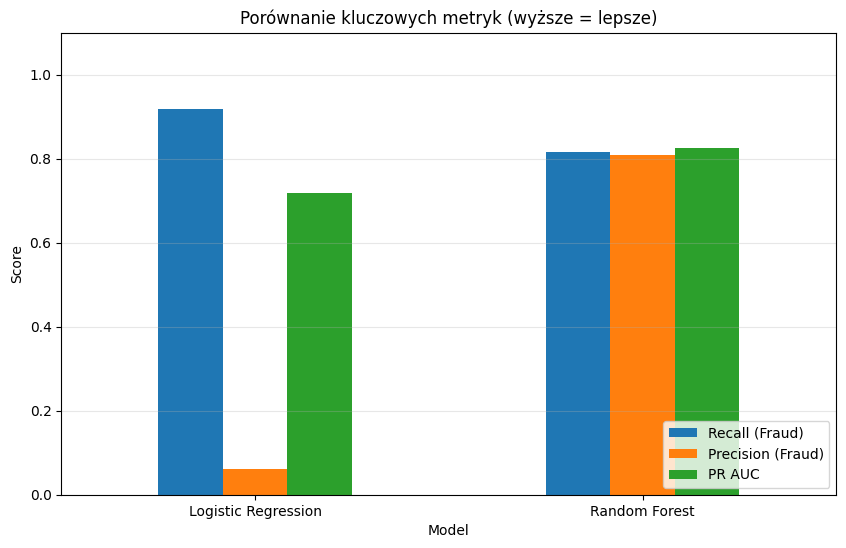

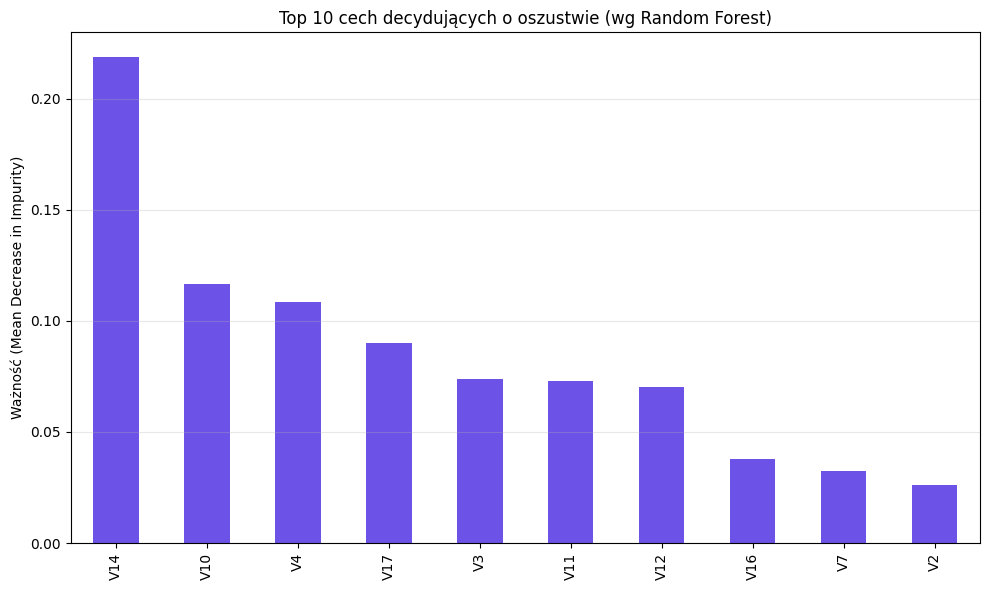

In [27]:

comparison_df = pd.DataFrame([lr_results, rf_results])
comparison_df = comparison_df.set_index('Model')

print("\n--- ZESTAWIENIE WYNIKÓW ---")
print(comparison_df)

comparison_df[['Recall (Fraud)', 'Precision (Fraud)', 'PR AUC']].plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('Porównanie kluczowych metryk (wyższe = lepsze)')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)
plt.legend(loc='lower right')
plt.show()


importances = rf_model.feature_importances_
feature_names = X_train.columns

forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
forest_importances.head(10).plot(kind='bar', color='#6D52E7')
plt.title("Top 10 cech decydujących o oszustwie (wg Random Forest)")
plt.ylabel("Ważność (Mean Decrease in Impurity)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Wnioski

Oba modele mają wysoką skuteczność (recall) w wkrywaniu oszustw, jednak Random Forest okazał się być o wiele bardziej użytecznym modelem pod względem biznesowym. 

Oto dlaczego:

1. Prezycja to kluczowa metryka określająca sukces
- Logistic Regression generuje dużo False Positives, które znacząco wpływają na negatywny user experience w postaci niesłusznego blokowania kart użytkowników.
- Random Forest, w przeciwieństwie do Logistic Regression posiada nieliniową granice decyzyjną, co powoduje odportność na outliery.

2. Featture Importance
- Random Forest pozwala wygenerować ranking ważności cech, co w tym konkretnym przypadku może mieć kluczowe znaczenie.
